In [1]:
#uploading the the csv file  of 05 feb 2026(the market)
#in file we have one FUT(underlying stock) and many Europeon call/put options
#we have data of spot rate of stock(FUT), premium price of options(last Trade price) for every minute

In [2]:
from google.colab import files

uploaded = files.upload()

# Get the name of the uploaded file
if uploaded:
    uploaded_file_name = list(uploaded.keys())[0]
    print(f"File '{uploaded_file_name}' uploaded successfully.")
else:
    print("No file was uploaded.")

Saving 20260205_option_minute_prices_expiry.csv to 20260205_option_minute_prices_expiry.csv
File '20260205_option_minute_prices_expiry.csv' uploaded successfully.


In [3]:
import pandas as pd

# Use the name of the uploaded file to load the DataFrame
file_name = uploaded_file_name
df_feb05 = pd.read_csv(file_name)

print(f"Successfully loaded '{file_name}' into a DataFrame.")

# Display the first 5 rows to verify
display(df_feb05.head())

Successfully loaded '20260205_option_minute_prices_expiry.csv' into a DataFrame.


,date,minute_end,symbol,last_trade_price
0,20260205,91600,NIFTY26FEBFUT,2578540.0
1,20260205,91600,NIFTY2621025600CE,23115.0
2,20260205,91600,NIFTY2621025650CE,19995.0
3,20260205,91600,NIFTY2621025700CE,17140.0
4,20260205,91600,NIFTY2621025750CE,14535.0


In [4]:
#data uplaoded successfully
#here the FUT price,option price in in paisa so will make them in rupees
#strike price is already in rupees
#made a options_df for every options availaable on 11:00:00
#fileterd_df is df at 11:00:00


#Assumptions(can be improved on this)
# Risk free rate =5%, time to expiry 15:30:00, time to start 11:00:00
#Hardcoded expiry date — fine for a single-day notebook, but should be parameterized if you generalize this to other dates.
#strike[-5:] — assumes a fixed 5-digit strike; will break for 4-digit or 6-digit strikes.


In [5]:
import numpy as np
import pandas as pd

# Filter for 11 AM (11:00:00)
# Ensure 'minute_end' is treated as an integer for filtering
filtered_df = df_feb05[df_feb05['minute_end'] == 110000].copy()

# Extract Future Price
futures_row = filtered_df[filtered_df['symbol'].str.contains('FUT')]
if not futures_row.empty:
    S_paisa = futures_row['last_trade_price'].iloc[0]
    S = S_paisa/100.0 # Convert paisa to rupees
    print(f"Future Price (S) at 11 AM (in rupees): {S}")
else:
    S = None
    print("Future price not found at 11 AM. Cannot calculate Greeks or IV without S.")

# Filter out the futures row from the options data
options_df = filtered_df[~filtered_df['symbol'].str.contains('FUT')].copy()

# Parse option symbols to get Strike Price and Option Type (CE/PE)
def parse_symbol(symbol):
    option_type = None
    strike = None

    if 'CE' in symbol:
        option_type = 'call'
        strike_part = symbol.split('CE')[0]
        # Extract last 5 digits from the numeric part before 'CE'
        digits_only = ''.join(filter(str.isdigit, strike_part))
        if len(digits_only) >= 5:
            strike = float(digits_only[-5:])
    elif 'PE' in symbol:
        option_type = 'put'
        strike_part = symbol.split('PE')[0]
        # Extract last 5 digits from the numeric part before 'PE'
        digits_only = ''.join(filter(str.isdigit, strike_part))
        if len(digits_only) >= 5:
            strike = float(digits_only[-5:])

    return strike, option_type

options_df[['strike', 'option_type']] = options_df['symbol'].apply(lambda x: pd.Series(parse_symbol(x)))

# Convert strike and last_trade_price from paisa to rupees

options_df['last_trade_price'] = options_df['last_trade_price']/100.0

# Drop rows where parsing failed or strike is None
options_df.dropna(subset=['strike', 'option_type'], inplace=True)

# Combine 'date' (e.g., 20260205) and 'minute_end' (e.g., 110000) into a single datetime object
options_df['observation_datetime_str'] = options_df['date'].astype(str) + options_df['minute_end'].astype(str).str.zfill(6)
options_df['observation_datetime'] = pd.to_datetime(options_df['observation_datetime_str'], format='%Y%m%d%H%M%S')

# User specified expiration date and time: 0502 (Feb 5th) at 3:30 PM (15:30)
expiration_date = pd.to_datetime('2026-02-05 15:30:00')

# Calculate Time to Expiration (T) in years
# dt.total_seconds() gives seconds, then convert to years
options_df['T'] = (expiration_date - options_df['observation_datetime']).dt.total_seconds() / (365.25 * 24 * 3600)

# Assume a risk-free rate (r)
r = 0.05 # 5%

print(f"Number of options at 11 AM: {len(options_df)}")
display(options_df)

Future Price (S) at 11 AM (in rupees): 25715.1
Number of options at 11 AM: 22


,date,minute_end,symbol,last_trade_price,strike,option_type,observation_datetime_str,observation_datetime,T
2393,20260205,110000,NIFTY2621025600CE,167.90,25600.0,call,20260205110000,2026-02-05 11:00:00,0.000513
2394,20260205,110000,NIFTY2621025650CE,141.15,25650.0,call,20260205110000,2026-02-05 11:00:00,0.000513
2395,20260205,110000,NIFTY2621025700CE,117.70,25700.0,call,20260205110000,2026-02-05 11:00:00,0.000513
2396,20260205,110000,NIFTY2621025750CE,97.25,25750.0,call,20260205110000,2026-02-05 11:00:00,0.000513
2397,20260205,110000,NIFTY2621025800CE,79.90,25800.0,call,20260205110000,2026-02-05 11:00:00,0.000513
2398,20260205,110000,NIFTY2621025850CE,64.90,25850.0,call,20260205110000,2026-02-05 11:00:00,0.000513
2399,20260205,110000,NIFTY2621025900CE,52.75,25900.0,call,20260205110000,2026-02-05 11:00:00,0.000513
2400,20260205,110000,NIFTY2621025950CE,42.60,25950.0,call,20260205110000,2026-02-05 11:00:00,0.000513
2401,20260205,110000,NIFTY2621026000CE,34.95,26000.0,call,20260205110000,2026-02-05 11:00:00,0.000513
2402,20260205,110000,NIFTY2621026050CE,27.95,26050.0,call,20260205110000,2026-02-05 11:00:00,0.000513


In [6]:
#defeined balck scholes equation for finding the delta (and other greeks if u want
#defined impliead_volatitliy equation for finding the sigma that is needed to calculate delta(d1)
#since we have option prices(observed prices), we reverse engineer it using bisection method to find volatility
#also made a time_series_merged where we cna see every minute option price change


#assumptions(can be improved)
#consdered  low_vol = 0.001
    #high_vol = 5.0
    #NIFTY2621025700CE

    #no transactions c0st in P&L
    #discrete time interval of 375
    #only one stock price path

Starting Delta Hedging Simulation for Call option with Strike 25700.0 using Implied Volatility
Risk-free rate (r) = 0.05
Dataset contains 375 price points from 2026-02-05 09:16:00 to 2026-02-05 15:30:00.

--- Delta Hedging Results (using Implied Volatility) ---
Final Underlying Price (S_T): 25720.00
Option Payoff at Expiry (-Z_T, from hedger's perspective): -20.00
Cumulative Trading P&L from Delta Hedging: -48.76
Total P&L from Delta Hedging (PL_T): -68.76


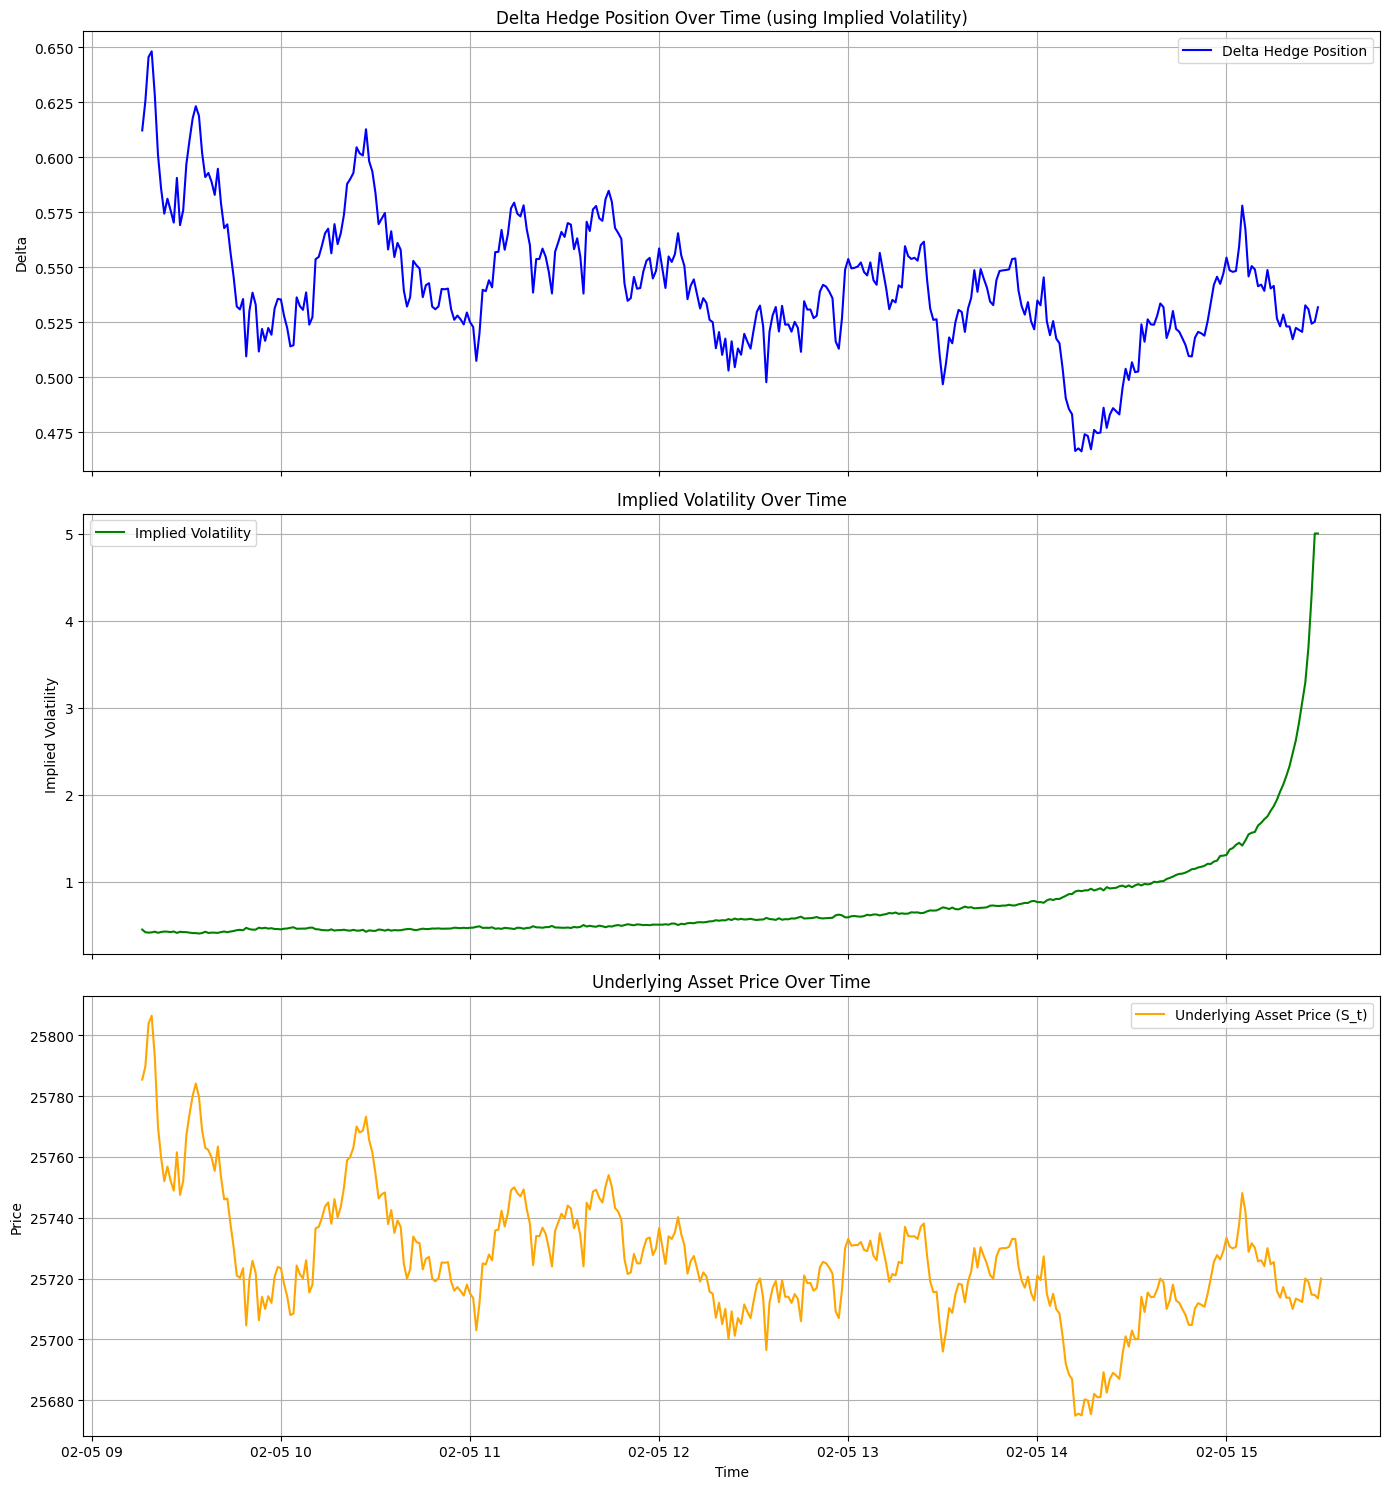

In [7]:
import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt
import seaborn as sns

# --- Black-Scholes function (assuming it's defined in a previous cell, included here for context) ---
def black_scholes(S, K, T, r, sigma, option_type):
    if T <= 0: # Handle zero or negative time to expiration
        if option_type == 'call':
            delta = 1.0 if S > K else 0.0
            return max(0, S - K), delta, 0, 0
        else:
            delta = -1.0 if S < K else 0.0
            return max(0, K - S), delta, 0, 0

    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if option_type == 'call':
        price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
        delta = norm.cdf(d1)
        gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))
        theta = -(S * norm.pdf(d1) * sigma) / (2 * np.sqrt(T)) - r * K * np.exp(-r * T) * norm.cdf(d2)
    elif option_type == 'put':
        price = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1) # Corrected put price formula
        delta = norm.cdf(d1) - 1
        gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))
        theta = -(S * norm.pdf(d1) * sigma) / (2 * np.sqrt(T)) + r * K * np.exp(-r * T) * norm.cdf(-d2)
    else:
        raise ValueError("option_type must be 'call' or 'put'")

    return price, delta, gamma, theta

# --- Implied Volatility solver (re-defined for clarity, assuming it's available from previous steps) ---
def implied_volatility(observed_price, S, K, T, r, option_type, tol=1e-5, max_iter=100):
    low_vol = 0.001
    high_vol = 5.0

    if T <= 0:
        return 0 # Or handle appropriately, e.g., NaN if IV is not applicable at expiry

    for i in range(max_iter):
        mid_vol = (low_vol + high_vol) / 2

        if mid_vol < 1e-6:
            mid_vol = 1e-6

        bs_price, _, _, _ = black_scholes(S, K, T, r, mid_vol, option_type)

        if abs(bs_price - observed_price) < tol:
            return mid_vol

        if bs_price < observed_price:
            low_vol = mid_vol
        else:
            high_vol = mid_vol

        if (high_vol - low_vol) < tol:
            return mid_vol

    return mid_vol # Return the best guess if max_iter reached

# --- Delta Hedging Implementation with Implied Volatility ---

# 1. Identify the target ATM option: NIFTY2621025700CE (Strike 2570000, Call)
target_strike = 25700.0
target_option_type = 'call'
target_symbol_contains = 'NIFTY2621025700CE' # Specific symbol for the option

# Parameters for Black-Scholes and hedging
K = target_strike
r = 0.05 # Risk-free rate

# Prepare the full DataFrame for minute-by-minute simulation
df_iv_hedge = df_feb05.copy()

df_iv_hedge['observation_datetime_str'] = df_iv_hedge['date'].astype(str) + \
                                             df_iv_hedge['minute_end'].astype(str).str.zfill(6)
df_iv_hedge['observation_datetime'] = pd.to_datetime(df_iv_hedge['observation_datetime_str'], format='%Y%m%d%H%M%S')

# User specified expiration date and time: 0502 (Feb 5th) at 3:30 PM (15:30)
expiration_date = pd.to_datetime('2026-02-05 15:30:00')

# Get the time series data for future prices and the target option
future_prices_df = df_iv_hedge[df_iv_hedge['symbol'].str.contains('FUT')].copy()
option_prices_df = df_iv_hedge[df_iv_hedge['symbol'] == target_symbol_contains].copy()

# Merge them to ensure synchronized time steps
time_series_merged = pd.merge(future_prices_df, option_prices_df,
                              on='observation_datetime', suffixes=('_fut', '_opt'))
time_series_merged = time_series_merged.sort_values('observation_datetime').reset_index(drop=True)

# Calculate Time to Expiration (T) in years for each minute on the merged DataFrame
time_series_merged['T'] = (expiration_date - time_series_merged['observation_datetime']).dt.total_seconds() / (365.25 * 24 * 3600)

time_series_merged['last_trade_price_fut'] = time_series_merged['last_trade_price_fut'] / 100.0
time_series_merged['last_trade_price_opt'] = time_series_merged['last_trade_price_opt'] / 100.0

# Initialize hedging variables
cumulative_trading_pnl_iv_hedge = 0.0
delta_history_iv = []
iv_history = []
asset_price_history_iv = []

print(f"Starting Delta Hedging Simulation for {target_option_type.capitalize()} option with Strike {K} using Implied Volatility")
print(f"Risk-free rate (r) = {r}")

# Print information about the price points
num_price_points = len(time_series_merged)
first_timestamp = time_series_merged['observation_datetime'].min()
last_timestamp = time_series_merged['observation_datetime'].max()
print(f"Dataset contains {num_price_points} price points from {first_timestamp} to {last_timestamp}.")

# Loop through the time series data for delta hedging (up to the second to last minute)
for i in range(len(time_series_merged) - 1):
    S_ti = time_series_merged['last_trade_price_fut'].iloc[i]
    observed_option_price_ti = time_series_merged['last_trade_price_opt'].iloc[i]
    T_ti = time_series_merged['T'].iloc[i]

    # Calculate Implied Volatility at time t_i
    current_iv = implied_volatility(observed_option_price_ti, S_ti, K, T_ti, r, target_option_type)

    # If IV calculation fails or results in an invalid value, use a fallback (e.g., previous IV or a default)
    if pd.isna(current_iv) or current_iv <= 0:
        if iv_history: # Use previous IV if available
            current_iv = iv_history[-1]
        else: # Fallback to a default if no previous IV exists (e.g., initial fixed sigma)
            current_iv = 0.6 # This is similar to the fixed sigma in the previous step

    # Calculate delta at time t_i using Black-Scholes with the current implied volatility
    _, current_delta, _, _ = black_scholes(S_ti, K, T_ti, r, current_iv, target_option_type)

    delta_history_iv.append(current_delta)
    iv_history.append(current_iv)
    asset_price_history_iv.append(S_ti)

    # Get the price at the next minute (S_{ti+1})
    S_ti_plus_1 = time_series_merged['last_trade_price_fut'].iloc[i+1]

    # Contribution to P&L for this interval: delta_ti * (S_{ti+1} - S_ti)
    pnl_this_interval = current_delta * (S_ti_plus_1 - S_ti)
    cumulative_trading_pnl_iv_hedge += pnl_this_interval

# Final asset price at expiry (S_T is the last future price in the series)
S_T = time_series_merged['last_trade_price_fut'].iloc[-1]

# Calculate the option's payoff at expiry (Z_T) for the hedger (who sold the option)
if target_option_type == 'call':
    option_payoff_at_expiry = max(0, S_T - K)
elif target_option_type == 'put':
    option_payoff_at_expiry = max(0, K - S_T)
else:
    option_payoff_at_expiry = 0

# Calculate total PL_T using the provided formula (no transaction costs C_T(delta) = 0):
# PL_T = -Z_T + cumulative_trading_pnl - C_T(delta)
PL_T_iv_hedging = -option_payoff_at_expiry + cumulative_trading_pnl_iv_hedge

print(f"\n--- Delta Hedging Results (using Implied Volatility) ---")
print(f"Final Underlying Price (S_T): {S_T:.2f}")
print(f"Option Payoff at Expiry (-Z_T, from hedger's perspective): {-option_payoff_at_expiry:.2f}")
print(f"Cumulative Trading P&L from Delta Hedging: {cumulative_trading_pnl_iv_hedge:.2f}")
print(f"Total P&L from Delta Hedging (PL_T): {PL_T_iv_hedging:.2f}")

# --- Plotting the Delta, Implied Volatility, and Underlying Price ---
fig, axes = plt.subplots(3, 1, figsize=(14, 15), sharex=True)

# Plot 1: Delta Hedge Position
axes[0].plot(time_series_merged['observation_datetime'].iloc[:-1], delta_history_iv, label='Delta Hedge Position', color='blue')
axes[0].set_title('Delta Hedge Position Over Time (using Implied Volatility)')
axes[0].set_ylabel('Delta')
axes[0].grid(True)
axes[0].legend()

# Plot 2: Implied Volatility
axes[1].plot(time_series_merged['observation_datetime'].iloc[:-1], iv_history, label='Implied Volatility', color='green')
axes[1].set_title('Implied Volatility Over Time')
axes[1].set_ylabel('Implied Volatility')
axes[1].grid(True)
axes[1].legend()

# Plot 3: Underlying Asset Price
axes[2].plot(time_series_merged['observation_datetime'], time_series_merged['last_trade_price_fut'], label='Underlying Asset Price (S_t)', color='orange')
axes[2].set_title('Underlying Asset Price Over Time')
axes[2].set_xlabel('Time')
axes[2].set_ylabel('Price')
axes[2].grid(True)
axes[2].legend()

plt.tight_layout()
plt.show()

In [8]:
display(time_series_merged)

,date_fut,minute_end_fut,symbol_fut,last_trade_price_fut,observation_datetime_str_fut,observation_datetime,date_opt,minute_end_opt,symbol_opt,last_trade_price_opt,observation_datetime_str_opt,T
0,20260205,91600,NIFTY26FEBFUT,25785.4,20260205091600,2026-02-05 09:16:00,20260205,91600,NIFTY2621025700CE,171.40,20260205091600,0.000711
1,20260205,91700,NIFTY26FEBFUT,25789.7,20260205091700,2026-02-05 09:17:00,20260205,91700,NIFTY2621025700CE,165.90,20260205091700,0.000709
2,20260205,91800,NIFTY26FEBFUT,25803.8,20260205091800,2026-02-05 09:18:00,20260205,91800,NIFTY2621025700CE,173.60,20260205091800,0.000707
3,20260205,91900,NIFTY26FEBFUT,25806.4,20260205091900,2026-02-05 09:19:00,20260205,91900,NIFTY2621025700CE,175.85,20260205091900,0.000705
4,20260205,92000,NIFTY26FEBFUT,25792.6,20260205092000,2026-02-05 09:20:00,20260205,92000,NIFTY2621025700CE,169.00,20260205092000,0.000703
...,...,...,...,...,...,...,...,...,...,...,...,...
370,20260205,152600,NIFTY26FEBFUT,25718.9,20260205152600,2026-02-05 15:26:00,20260205,152600,NIFTY2621025700CE,114.20,20260205152600,0.000008
371,20260205,152700,NIFTY26FEBFUT,25714.7,20260205152700,2026-02-05 15:27:00,20260205,152700,NIFTY2621025700CE,112.65,20260205152700,0.000006
372,20260205,152800,NIFTY26FEBFUT,25714.6,20260205152800,2026-02-05 15:28:00,20260205,152800,NIFTY2621025700CE,111.40,20260205152800,0.000004
373,20260205,152900,NIFTY26FEBFUT,25713.5,20260205152900,2026-02-05 15:29:00,20260205,152900,NIFTY2621025700CE,110.55,20260205152900,0.000002


In [9]:
time_series_merged.shape

(375, 12)

***important note***

Here we see violation of the model's own assumption
Black-Scholes is derived under the explicit assumption that sigma is constant — fixed for the life of the option, known in advance, never changing. The entire derivation (the PDE, the closed-form formula, the delta-hedging argument that "proves" the formula) relies on that constancy. If you recompute IV fresh every single minute and get a different number each time, you are, strictly speaking, no longer inside the world the formula was derived for.

In [10]:
len(time_series_merged)

375

In [11]:
time_series_merged['last_trade_price_fut'].iloc[0]

np.float64(25785.4)

*Conclusions till now*

Final Underlying Price (S_T): 25720.00

Option Payoff at Expiry (-Z_T, from hedger's perspective): -20.00

Cumulative Trading P&L from Delta Hedging: -48.76

Total P&L from Delta Hedging (PL_T): -68.76

You can see that P&L loss increased after hedging , so is hedging bad(if we would have added transcations cost , it would be more too, no heding the delta wasnt developed for making profits, it was just invented to minimise your risk which it is doing by heding stocks, in this run we suffered a loss, thats why in next cells we took 1000 paths , to see if hedging helps

In [12]:
#To train our deep hedger, we need a large dataset of underlying asset price paths.
#We'll use Geometric Brownian Motion (GBM) to simulate these paths.
#GBM is a standard model for asset prices, assuming that prices follow a random walk with a constant drift and volatility.

**Generate Synthetic Price Paths using Geometric Brownian Motion (GBM)**

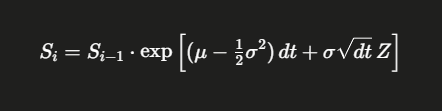

Z = np.random.normal(0,1) — draws one random

(mu - 0.5*sigma**2) * dt — the drift term.

sigma * np.sqrt(dt) * Z — the random/diffusion term

In [13]:
#assumptions
#S0 starting price of FUT at 11:00:00
#mu = r  risk-neutral measure (the standard assumption for option pricing)
#sigma = 0.6(volatiltiy)
#num_paths = 1000
#Have the same number of discrete time steps (e.g., minutes) as our real data.

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Parameters from our real market data
S0 = time_series_merged['last_trade_price_fut'].iloc[0] # Initial future price
num_steps = len(time_series_merged) - 1 # Number of minute intervals

# Calculate the total time in years (from start to end of the real data)
time_diff = (time_series_merged['observation_datetime'].iloc[-1] - time_series_merged['observation_datetime'].iloc[0]).total_seconds()
T_total_years = time_diff / (365.25 * 24 * 3600)
dt = T_total_years / num_steps # Time increment for each step

# GBM Parameters
mu = r # Drift (risk-free rate) for risk-neutral measure
sigma = 0.6 # Volatility as specified by the user
num_paths = 1000 # Number of price paths to generate (reverted to 1,000 as per user request)

def generate_gbm_path(S0, mu, sigma, dt, num_steps):
    '''Generates a single price path using Geometric Brownian Motion.'''
    prices = np.zeros(num_steps + 1)
    prices[0] = S0
    for i in range(1, num_steps + 1):
        # Z is a standard normal random variable
        Z = np.random.normal(0, 1)
        prices[i] = prices[i-1] * np.exp((mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z)
    return prices

# Generate multiple price paths
np.random.seed(42) # for reproducibility
synthetic_price_paths = []
for _ in range(num_paths):
    path = generate_gbm_path(S0, mu, sigma, dt, num_steps)
    synthetic_price_paths.append(path)

print(f"Generated {num_paths} synthetic price paths, each with {num_steps + 1} points.")
print(f"Initial price (S0): {S0:.2f}")
print(f"Drift (mu): {mu}")
print(f"Volatility (sigma): {sigma}")
print(f"Time step (dt) in years: {dt:.6f}")

Generated 1000 synthetic price paths, each with 375 points.
Initial price (S0): 25785.40
Drift (mu): 0.05
Volatility (sigma): 0.6
Time step (dt) in years: 0.000002


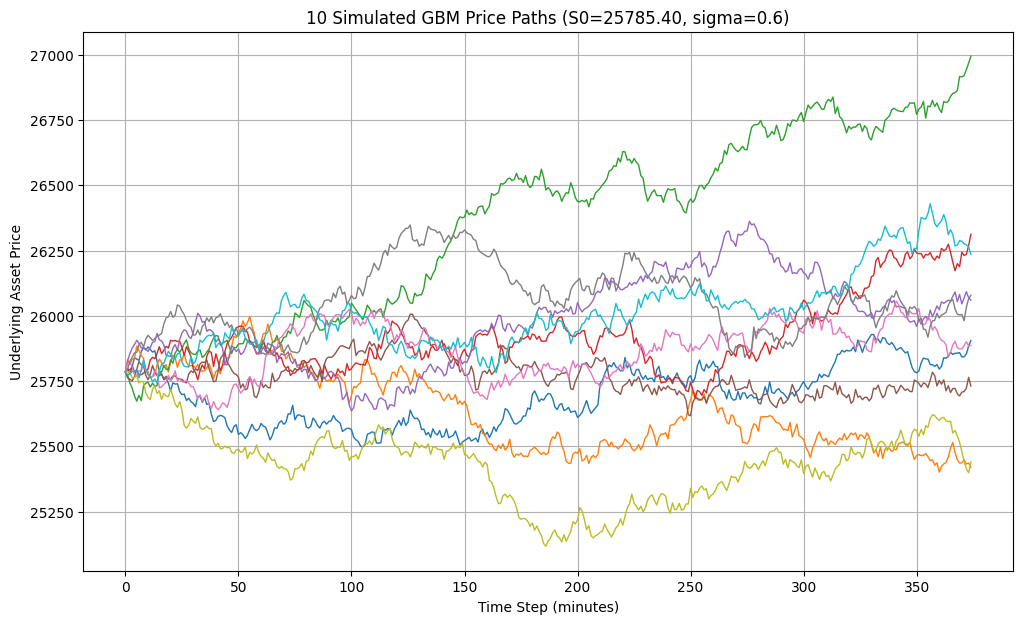

In [15]:
plt.figure(figsize=(12, 7))
for i in range(min(10, num_paths)): # Plot first 10 paths for clarity
    plt.plot(synthetic_price_paths[i], lw=1)
plt.title(f'{min(10, num_paths)} Simulated GBM Price Paths (S0={S0:.2f}, sigma={sigma})')
plt.xlabel('Time Step (minutes)')
plt.ylabel('Underlying Asset Price')
plt.grid(True)
plt.show()

###  Calculate Black-Scholes Option Prices and Deltas for Synthetic Paths

For each generated GBM path, we need to calculate the theoretical Black-Scholes option price and its corresponding Delta at each time step. These will serve as target values and input features for our deep hedging model.

In [16]:
# Option parameters for Black-Scholes calculation (same as the real data option)
option_K = target_strike # Strike price (from previous real data analysis)
option_r = r             # Risk-free rate (from previous real data analysis)
option_type = 'call'     # Target option type
cost_rate = 0.0006  # 0.06% of trade value per rebalance -- adjust based on what feels realistic for your asset

# We will use a constant volatility for these theoretical calculations,
# as the GBM paths were generated with a constant sigma (0.6). We'll use this.
theoretical_sigma = sigma # Use the same sigma as GBM generation (0.6)

# Prepare lists to store calculated Black-Scholes prices and deltas for all paths
all_bs_prices = []
all_bs_deltas = []

print(f"Calculating Black-Scholes prices and deltas for {num_paths} paths...")

# Iterate through each synthetic price path
for path_idx, s_path in enumerate(synthetic_price_paths):
    bs_prices_for_path = []
    bs_deltas_for_path = []

    # Iterate through each time step in the path
    for t_step in range(num_steps + 1):
        S_t = s_path[t_step]

        # Calculate time to expiration for this step
        # T decreases over time. T_total_years is the initial total time.
        # The remaining time is T_total_years - (t_step * dt)
        T_remaining = T_total_years - (t_step * dt)

        # Ensure T_remaining is not negative due to floating point precision at expiry
        if T_remaining < 0: T_remaining = 0

        # Calculate Black-Scholes price and delta
        price, delta, _, _ = black_scholes(S_t, option_K, T_remaining, option_r, theoretical_sigma, option_type)

        bs_prices_for_path.append(price)
        bs_deltas_for_path.append(delta)

    all_bs_prices.append(np.array(bs_prices_for_path))
    all_bs_deltas.append(np.array(bs_deltas_for_path))

# Convert to numpy arrays for easier manipulation
all_bs_prices = np.array(all_bs_prices)
all_bs_deltas = np.array(all_bs_deltas)

print(f"Finished calculating BS prices and deltas. Shape: {all_bs_prices.shape}")

# Display a sample (e.g., first path's prices and deltas)
print("\nSample Black-Scholes Prices for the first path (first 5 and last 5):")
print(all_bs_prices[0, :5])
print(all_bs_prices[0, -5:])

print("\nSample Black-Scholes Deltas for the first path (first 5 and last 5):")
print(all_bs_deltas[0, :5])
print(all_bs_deltas[0, -5:])

Calculating Black-Scholes prices and deltas for 1000 paths...
Finished calculating BS prices and deltas. Shape: (1000, 375)

Sample Black-Scholes Prices for the first path (first 5 and last 5):
[211.06117509 217.10697984 215.13222503 223.20920575 243.224968  ]
[142.65039063 143.16148324 153.80190658 184.85084002 205.39304787]

Sample Black-Scholes Deltas for the first path (first 5 and last 5):
[0.58611674 0.5962043  0.59353584 0.60663222 0.63685054]
[0.99959007 0.99994719 0.99999983 1.         1.        ]


**Split Data into Training and Test Sets**

In [17]:
#now we split the 1000 paths in the ratio 4:1 for training and testing respectively

In [18]:
from sklearn.model_selection import train_test_split

# Convert lists of arrays to a single numpy array if not already
synthetic_price_paths_array = np.array(synthetic_price_paths)

# Define the split ratio (e.g., 80% for training, 20% for testing)
test_size_ratio = 0.2

# Split the synthetic price paths
S_train, S_test = train_test_split(synthetic_price_paths_array, test_size=test_size_ratio, random_state=42)

# Split the corresponding Black-Scholes prices
BS_prices_train, BS_prices_test = train_test_split(all_bs_prices, test_size=test_size_ratio, random_state=42)

# Split the corresponding Black-Scholes deltas
BS_deltas_train, BS_deltas_test = train_test_split(all_bs_deltas, test_size=test_size_ratio, random_state=42)

print(f"Training set size: {len(S_train)} paths")
print(f"Test set size: {len(S_test)} paths")

print(f"Shape of S_train: {S_train.shape}")
print(f"Shape of BS_deltas_train: {BS_deltas_train.shape}")

Training set size: 800 paths
Test set size: 200 paths
Shape of S_train: (800, 375)
Shape of BS_deltas_train: (800, 375)


## 7. Deep Hedging Network Architecture (Gated Recurrent Unit)

### Concept
Based on the foundational framework established by Buehler et al. (2019) in *"Deep Hedging"*, we replace manual multi-period programming with a Recurrent Neural Network (RNN) architecture. The objective is to map sequential market features directly to an optimized, transaction-cost-aware trading strategy.

### Structural Framework
* **Input Layer:** Accepts a 3-dimensional tensor containing both the localized price path and corresponding Black-Scholes baseline deltas.
* **Gated Recurrent Units (GRU):** We deploy a 64-unit GRU layer configured with `return_sequences=True`. The internal hidden state vectors function as sequential memory, implicitly mapping past inventory choices, execution paths, and current positions without needing an explicit lag tracking loop.
* **Time-Distributed Projection:** A `TimeDistributed` Dense layer with a `sigmoid` activation maps the GRU's hidden representations into a bounded $[0, 1]$ interval output at *every single time step*, outputting the target asset position ($\Delta_t$) to hold for the upcoming interval.

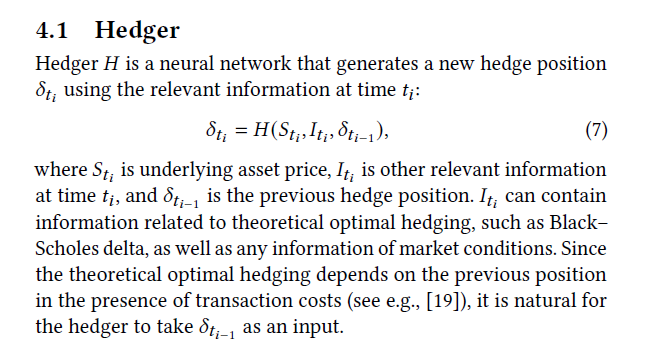

In [19]:
import numpy as np

# ============================================================
# RESHAPE DATA FOR THE GRU MODEL
# ============================================================
# The GRU model expects each input tensor as (num_paths, num_time_steps, 1)
# -- i.e. every individual scalar (price, BS-delta) wrapped in its own
# 1-element "feature" dimension. Our existing arrays from earlier cells
# are (num_paths, num_time_steps) -- missing that last dimension.
#
# np.expand_dims(arr, axis=-1) inserts a new axis of size 1 at the END.
# Example: shape (800, 375)  -->  (800, 375, 1)
# This does NOT change any values, only adds a dimension so Keras can
# treat each time step as having "1 feature" instead of being a bare scalar.
# ============================================================

S_train_gru = np.expand_dims(S_train, axis=-1).astype(np.float32)
S_test_gru  = np.expand_dims(S_test,  axis=-1).astype(np.float32)

BS_deltas_train_gru = np.expand_dims(BS_deltas_train, axis=-1).astype(np.float32)
BS_deltas_test_gru  = np.expand_dims(BS_deltas_test,  axis=-1).astype(np.float32)

print("Shapes after reshape (should be (num_paths, num_time_steps, 1)):")
print(f"S_train_gru:        {S_train_gru.shape}")
print(f"S_test_gru:         {S_test_gru.shape}")
print(f"BS_deltas_train_gru: {BS_deltas_train_gru.shape}")
print(f"BS_deltas_test_gru:  {BS_deltas_test_gru.shape}")

# Sanity check: confirm values are unchanged, just reshaped
# (compares the first path's first 3 prices before vs after reshape)
print("\nSanity check (first path, first 3 steps):")
print("Original S_train[0, :3]:        ", S_train[0, :3])
print("Reshaped S_train_gru[0, :3, 0]: ", S_train_gru[0, :3, 0])

Shapes after reshape (should be (num_paths, num_time_steps, 1)):
S_train_gru:        (800, 375, 1)
S_test_gru:         (200, 375, 1)
BS_deltas_train_gru: (800, 375, 1)
BS_deltas_test_gru:  (200, 375, 1)

Sanity check (first path, first 3 steps):
Original S_train[0, :3]:         [25785.4        25812.50245028 25840.16610672]
Reshaped S_train_gru[0, :3, 0]:  [25785.4   25812.502 25840.166]


In [20]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, GRU, Dense, Concatenate, TimeDistributed

num_gru_units = 64  # Increased to handle the extra time information
num_time_steps = S_train_gru.shape[1] # 375

# --- 1. Define the 3 Inputs ---
s_input = Input(shape=(num_time_steps, 1), name='S_path_input')
bs_delta_input = Input(shape=(num_time_steps, 1), name='BS_delta_path_input')
t_remaining_input = Input(shape=(num_time_steps, 1), name='T_remaining_input') # <-- NEW

# --- 2. Combine all 3 features ---
combined_features = Concatenate(axis=-1)([s_input, bs_delta_input, t_remaining_input])

# --- 3. Process through GRU ---
gru_output = GRU(num_gru_units, activation='tanh', return_sequences=True, name='gru_layer')(combined_features)
output_delta = TimeDistributed(Dense(1, activation='sigmoid'), name='delta_output')(gru_output)

# --- 4. Build Model ---
deep_hedger_gru_model = Model(inputs=[s_input, bs_delta_input, t_remaining_input], outputs=output_delta)
deep_hedger_gru_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ S_path_input        │ (None, 375, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ BS_delta_path_input │ (None, 375, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ T_remaining_input   │ (None, 375, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 375, 3)    │          0 │ S_path_input[0][… │
│ (Concatenate)       │                   │            │ BS_delta_path_in… │
│                     │                   │            │ T_remaining_inpu… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_layer (GRU)     │ (None, 375, 64)   │     13,248 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ delta_output        │ (None, 375, 1)    │         65 │ gru_layer[0][0]   │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 13,313 (52.00 KB)

 Trainable params: 13,313 (52.00 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
import numpy as np

# Create a single sequence of time-to-expiry values (counting down to 0)
# T_total_years and dt are already defined from your GBM generation cell
t_steps = np.arange(num_time_steps)
T_remaining_single_path = np.maximum(0.0, T_total_years - (t_steps * dt))

# Duplicate this countdown for every path in the train and test sets
T_train = np.tile(T_remaining_single_path, (S_train.shape[0], 1))  # Shape: (800, 375)
T_test = np.tile(T_remaining_single_path, (S_test.shape[0], 1))    # Shape: (200, 375)

# Add the feature dimension so it matches the GRU expected shape (batch, 375, 1)
T_train_gru = np.expand_dims(T_train, axis=-1).astype(np.float32)
T_test_gru = np.expand_dims(T_test, axis=-1).astype(np.float32)

print("Shapes of T_remaining:")
print("T_train_gru:", T_train_gru.shape)
print("T_test_gru:", T_test_gru.shape)

Shapes of T_remaining:
T_train_gru: (800, 375, 1)
T_test_gru: (200, 375, 1)


**Define P&L Calculation and CVaR Loss Function (TensorFlow-compatible)**


To train our deep hedger using CVaR as a loss function, we first need a TensorFlow-compatible way to calculate the P&L for a given hedging strategy (sequence of deltas) and a price path. Then, we'll define the CVaR loss itself.


P&L Calculation Function
This function will simulate the hedging process for a given path and sequence of deltas generated by the model. It will calculate the total P&L at expiry.


CVaR Loss Function
CVaR (Conditional Value at Risk), also known as Expected Shortfall, measures the expected loss beyond a certain percentile (VaR). For a hedging problem, we want to minimize the expected losses in the worst-case scenarios. If P is the distribution of P&L values, and alpha is the confidence level (e.g., 0.05 for 5%), then CVaR( α ) is the expected P&L conditional on the P&L being below the  α -percentile (the VaR).

CVaRα=E[PL|PL≤VaRα]

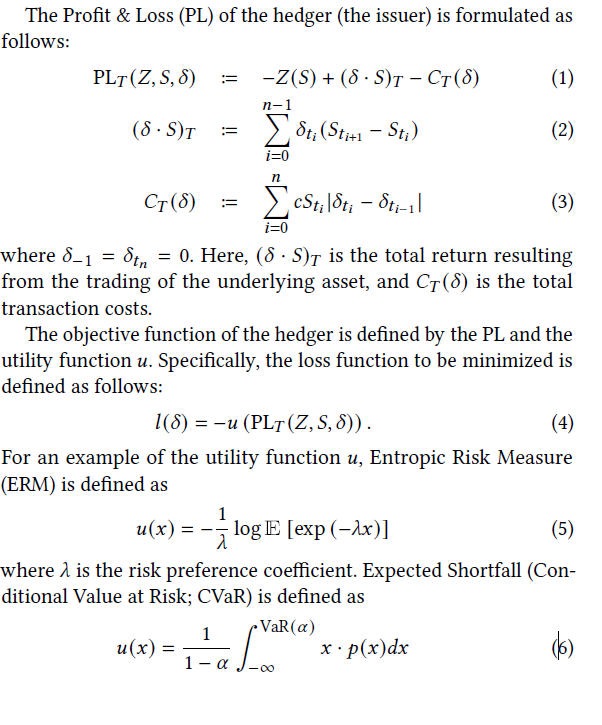

In [22]:
import tensorflow as tf

# Assuming option_K, r, option_type, dt are already defined globally or passed
# target_strike, r, option_type, dt

@tf.function
def calculate_pnl(S_path_batch, deltas_batch, K, r_tf, option_type_str, cost_rate=0.0006):
    """
    Calculates the P&L for a batch of price paths and corresponding delta hedges,
    including proportional transaction costs.

    Args:
        S_path_batch (tf.Tensor): Batch of underlying price paths (batch_size, num_steps + 1).
        deltas_batch (tf.Tensor): Batch of delta hedges (batch_size, num_steps + 1).
                                 deltas_batch[..., t] is the delta held from t to t+1.
        K (tf.Tensor): Strike price.
        r_tf (tf.Tensor): Risk-free rate.
        option_type_str (tf.Tensor): String tensor indicating 'call' or 'put'.
        cost_rate (float): Proportional transaction cost per unit of delta traded,
                            charged on the rupee value of the trade. Default 0.0
                            reproduces the original frictionless behavior.

    Returns:
        tf.Tensor: A tensor of P&L values for each path in the batch (batch_size,).
    """
    # Ensure tensors are float32 for consistency
    S_path_batch = tf.cast(S_path_batch, tf.float32)
    deltas_batch = tf.cast(deltas_batch, tf.float32)
    K = tf.cast(K, tf.float32)
    r_tf = tf.cast(r_tf, tf.float32)
    cost_rate = tf.cast(cost_rate, tf.float32)

    # Reshape deltas_batch to (batch_size, num_steps + 1) if it's (batch_size, num_steps + 1, 1)
    if len(deltas_batch.shape) == 3: # Handle case where delta_output is (batch_size, timesteps, 1)
        deltas_batch = tf.squeeze(deltas_batch, axis=-1)

    # S_t is S_path_batch[:, :-1]
    # S_{t+1} is S_path_batch[:, 1:]
    price_changes = S_path_batch[:, 1:] - S_path_batch[:, :-1]

    # Delta position at time t is held from t to t+1. So we use deltas_batch[:, :-1] (or just deltas_batch) for trading P&L
    # The last delta in deltas_batch is the delta at expiry, which contributes to the final option value, not trading PnL
    # This matches the (delta . S)_T definition in the paper where delta_ti is for (S_{ti+1} - S_ti)
    trading_pnl_per_interval = deltas_batch[:, :-1] * price_changes
    cumulative_trading_pnl = tf.reduce_sum(trading_pnl_per_interval, axis=1)

    # A trade happens whenever the hedge position CHANGES from one step to the next.
    # delta_changes[t] = |delta_t - delta_{t-1}|  -- the SIZE of the trade made at step t.
    # Cost is charged proportionally to the rupee value of that trade
    # (trade size in delta units x price at which the trade happens x cost_rate).
    delta_changes = tf.abs(deltas_batch[:, 1:] - deltas_batch[:, :-1])  # (batch_size, num_steps - 1)
    # S_path_batch[:, 1:] aligns the trade made when MOVING INTO step t+1 with the
    # price prevailing at that same step t+1 -- consistent with how price_changes was defined above.
    transaction_costs_per_interval = cost_rate * delta_changes * S_path_batch[:, 1:]
    total_transaction_costs = tf.reduce_sum(transaction_costs_per_interval, axis=1)

    # Option payoff at expiry (Z_T)
    S_T = S_path_batch[:, -1] # Final underlying price

    # Check option type using tf.strings.equal
    is_call = tf.cast(tf.strings.bytes_split(option_type_str)[0] == tf.constant(b'c'), tf.float32)

    option_payoff_at_expiry_call = tf.maximum(0.0, S_T - K)
    option_payoff_at_expiry_put = tf.maximum(0.0, K - S_T)

    # Use tf.where to select based on option type
    option_payoff_at_expiry = tf.where(
        tf.cast(is_call, tf.bool),
        option_payoff_at_expiry_call,
        option_payoff_at_expiry_put
    )

    # Total P&L: -Z_T + cumulative_trading_pnl - transaction_costs
    total_pnl = -option_payoff_at_expiry + cumulative_trading_pnl - total_transaction_costs

    return total_pnl

print("calculate_pnl redefined with transaction cost support (cost_rate=0.0 default = old behavior).")

@tf.function
def cvar_loss(pnl_values, alpha=0.05):
    """
    Calculates the CVaR (Conditional Value at Risk) loss for a batch of P&L values.
    CVaR is the expected loss in the worst 'alpha' percentile.

    Args:
        pnl_values (tf.Tensor): A batch of P&L values (batch_size,).
        alpha (float): The significance level for CVaR (e.g., 0.05 for 5%).

    Returns:
        tf.Tensor: The CVaR loss (scalar).
    """
    # Sort P&L values in ascending order (from worst loss to best profit)
    sorted_pnl = tf.sort(pnl_values)

    # Calculate the index for VaR_alpha (worst 'alpha' percentage)
    num_samples = tf.cast(tf.shape(sorted_pnl)[0], tf.float32)
    cvar_index = tf.cast(tf.floor(num_samples * alpha), tf.int32)

    # Select the worst 'alpha' percentile of P&L values
    # Note: tf.slice is exclusive of the end index, so we need to go up to cvar_index
    worst_pnl_values = sorted_pnl[:cvar_index + 1] # Include up to the alpha-th percentile

    # CVaR is the negative of the average of these worst P&L values
    # We want to minimize the loss, so we minimize -CVaR or maximize CVaR.
    # Conventionally, CVaR is expressed as a positive loss, so we take the negative mean of P&L
    # PNL is profit, so minimizing average PNL means making profits smaller.
    # If PNL is negative (a loss), then -PNL is positive, and minimizing it means minimizing the loss.
    # So, CVaR loss will be -mean(worst_pnl_values)
    cvar_value = -tf.reduce_mean(worst_pnl_values)

    return cvar_value

print("TensorFlow-compatible P&L calculation and CVaR loss functions defined.")

calculate_pnl redefined with transaction cost support (cost_rate=0.0 default = old behavior).
TensorFlow-compatible P&L calculation and CVaR loss functions defined.


In [23]:
#implement the training process

In [24]:
import tensorflow as tf

# ============================================================
#  TRAINING LOOP -- GRU VERSION
# ============================================================

# Create a learning rate that starts high (0.005) but shrinks over time
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.005,
    decay_steps=500,
    decay_rate=0.90
)

# Pass the schedule to the optimizer instead of a fixed number
optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)
epochs = 100
batch_size = 1024

num_train_paths = S_train_gru.shape[0]   # 800
num_time_steps = S_train_gru.shape[1]    # 375  (kept for reference/printing)

# --- Build a tf.data pipeline ---
# Add T_train_gru to the dataset pipeline
train_dataset = tf.data.Dataset.from_tensor_slices(
    (S_train_gru, BS_deltas_train_gru, T_train_gru) # <-- Added T_train_gru
).shuffle(num_train_paths).batch(batch_size)

print(f"Starting CVaR-based Deep Hedging Training (GRU) for {epochs} epochs...")

cvar_history = []

for epoch in range(epochs):
    epoch_loss_avg = tf.keras.metrics.Mean()

   # Unpack the 3 variables
    for step, (batch_S_paths, batch_BS_deltas, batch_T) in enumerate(train_dataset):
        with tf.GradientTape() as tape:

            normalized_S_paths = tf.math.log(batch_S_paths / tf.constant(option_K, dtype=tf.float32))

            # Pass all 3 inputs into the model
            predicted_deltas = deep_hedger_gru_model([normalized_S_paths, batch_BS_deltas, batch_T])

            # ... (The rest of your P&L and loss code stays exactly the same)

            # BUT we squeeze and pass the RAW UNNORMALIZED paths to the P&L calculator
            batch_S_paths_2d = tf.squeeze(batch_S_paths, axis=-1)  # (batch_size, 375)

            # P&L using the model's OWN predicted deltas (not BS deltas)
            pnl_values = calculate_pnl(
                batch_S_paths_2d,
                predicted_deltas,
                tf.constant(option_K, dtype=tf.float32),
                tf.constant(option_r, dtype=tf.float32),
                tf.constant(option_type, dtype=tf.string),
                cost_rate=cost_rate
            )

            # --- MSE anchor term ---
            predicted_deltas_2d = tf.squeeze(predicted_deltas, axis=-1)   # (batch_size, 375)
            bs_deltas_2d = tf.squeeze(batch_BS_deltas, axis=-1)           # (batch_size, 375)
            mse_term = tf.reduce_mean(tf.square(predicted_deltas_2d - bs_deltas_2d))

            cvar_term = cvar_loss(pnl_values, alpha=0.05)

            # --- Combined loss ---
            # --- NEW: combined loss ---
            lambda_mse = 100000.0  # Scales up the tiny MSE gradients
            lambda_cvar = 1.0      # Weight on the CVaR term

            loss = (lambda_mse * mse_term) + (lambda_cvar * cvar_term)

        gradients = tape.gradient(loss, deep_hedger_gru_model.trainable_variables)
        optimizer.apply_gradients(zip(gradients, deep_hedger_gru_model.trainable_variables))

        epoch_loss_avg.update_state(loss)

    cvar_history.append(epoch_loss_avg.result().numpy())
    print(f"Epoch {epoch+1}/{epochs}, Total Loss: {epoch_loss_avg.result():.4f}")

print("\nGRU Deep Hedging Model Training Complete (CVaR objective).")

Starting CVaR-based Deep Hedging Training (GRU) for 100 epochs...
Epoch 1/100, Total Loss: 9848.6543
Epoch 2/100, Total Loss: 8303.7490
Epoch 3/100, Total Loss: 7456.9692
Epoch 4/100, Total Loss: 7041.5547
Epoch 5/100, Total Loss: 6734.3306
Epoch 6/100, Total Loss: 6355.5200
Epoch 7/100, Total Loss: 5839.2837
Epoch 8/100, Total Loss: 5250.9697
Epoch 9/100, Total Loss: 4644.3223
Epoch 10/100, Total Loss: 3970.9172
Epoch 11/100, Total Loss: 3148.9900
Epoch 12/100, Total Loss: 2133.9822
Epoch 13/100, Total Loss: 1154.5476
Epoch 14/100, Total Loss: 1306.0315
Epoch 15/100, Total Loss: 1944.9366
Epoch 16/100, Total Loss: 1807.8738
Epoch 17/100, Total Loss: 1092.6862
Epoch 18/100, Total Loss: 704.0676
Epoch 19/100, Total Loss: 739.9086
Epoch 20/100, Total Loss: 878.9700
Epoch 21/100, Total Loss: 949.4424
Epoch 22/100, Total Loss: 962.5249
Epoch 23/100, Total Loss: 943.8765
Epoch 24/100, Total Loss: 896.7005
Epoch 25/100, Total Loss: 818.4623
Epoch 26/100, Total Loss: 717.9340
Epoch 27/100, To

 **Evaluate Model Performance**


Now that the deep hedging model is trained, we need to evaluate its performance against the traditional Black-Scholes delta hedging strategy on both the synthetic training and test datasets. This will involve:


Calculating P&L for the Deep Hedger and Black-Scholes Delta Hedger for each path in the train and test sets.


Plotting P&L distributions (histograms) to visually compare the hedging effectiveness.


Quantifying risk by calculating Value at Risk (VaR) and Conditional Value at Risk (CVaR) for each scenario

In [25]:
print("Calculating P&L for Deep Hedger (GRU) on Train Set...")

normalized_S_train_gru = tf.math.log(S_train_gru / tf.constant(option_K, dtype=tf.float32))

BS_deltas_train_gru_tf = tf.constant(BS_deltas_train_gru, dtype=tf.float32)
T_train_gru_tf = tf.constant(T_train_gru, dtype=tf.float32)

dh_predicted_deltas_train = deep_hedger_gru_model([
    normalized_S_train_gru,
    BS_deltas_train_gru_tf,
    T_train_gru_tf
])

dh_pnl_train = calculate_pnl(
    tf.squeeze(S_train_gru, axis=-1),
    dh_predicted_deltas_train,
    tf.constant(option_K, dtype=tf.float32),
    tf.constant(option_r, dtype=tf.float32),
    tf.constant(option_type, dtype=tf.string),
    cost_rate=cost_rate
).numpy()

print("Calculating P&L for Deep Hedger (GRU) on Test Set...")

normalized_S_test_gru = tf.math.log(S_test_gru / tf.constant(option_K, dtype=tf.float32))

BS_deltas_test_gru_tf = tf.constant(BS_deltas_test_gru, dtype=tf.float32)
T_test_gru_tf = tf.constant(T_test_gru, dtype=tf.float32)

dh_predicted_deltas_test = deep_hedger_gru_model([
    normalized_S_test_gru,
    BS_deltas_test_gru_tf,
    T_test_gru_tf
])

dh_pnl_test = calculate_pnl(
    tf.squeeze(S_test_gru, axis=-1),
    dh_predicted_deltas_test,
    tf.constant(option_K, dtype=tf.float32),
    tf.constant(option_r, dtype=tf.float32),
    tf.constant(option_type, dtype=tf.string),
    cost_rate=cost_rate
).numpy()

print("Deep Hedger (GRU) P&L calculated for train and test sets.")
print(f"\nTrain P&L mean: {dh_pnl_train.mean():.2f}, std: {dh_pnl_train.std():.2f}")
print(f"Test P&L mean: {dh_pnl_test.mean():.2f}, std: {dh_pnl_test.std():.2f}")

Calculating P&L for Deep Hedger (GRU) on Train Set...
Calculating P&L for Deep Hedger (GRU) on Test Set...
Deep Hedger (GRU) P&L calculated for train and test sets.

Train P&L mean: -254.89, std: 27.96
Test P&L mean: -258.91, std: 27.81


In [26]:
print("Calculating P&L for Black-Scholes Delta Hedging on Train Set...")

# Black-Scholes Delta Hedging P&L on Train Set
bs_pnl_train = []
for path_idx in range(S_train.shape[0]):
    s_path = S_train[path_idx]
    # Use the pre-calculated Black-Scholes deltas directly
    bs_deltas_for_path_tf = tf.constant(BS_deltas_train[path_idx], dtype=tf.float32)

    pnl = calculate_pnl(
    tf.expand_dims(tf.constant(s_path, dtype=tf.float32), axis=0),
    tf.expand_dims(bs_deltas_for_path_tf, axis=0),
    tf.constant(option_K, dtype=tf.float32),
    tf.constant(option_r, dtype=tf.float32),
    tf.constant(option_type, dtype=tf.string),
    cost_rate=cost_rate   # <-- added
).numpy()[0]
    bs_pnl_train.append(pnl)
bs_pnl_train = np.array(bs_pnl_train)

print("Calculating P&L for Black-Scholes Delta Hedging on Test Set...")

# Black-Scholes Delta Hedging P&L on Test Set
bs_pnl_test = []
for path_idx in range(S_test.shape[0]):
    s_path = S_test[path_idx]
    # Use the pre-calculated Black-Scholes deltas directly
    bs_deltas_for_path_tf = tf.constant(BS_deltas_test[path_idx], dtype=tf.float32)

    pnl = calculate_pnl(
        tf.expand_dims(tf.constant(s_path, dtype=tf.float32), axis=0),
        tf.expand_dims(bs_deltas_for_path_tf, axis=0),
        tf.constant(option_K, dtype=tf.float32),
        tf.constant(option_r, dtype=tf.float32),
        tf.constant(option_type, dtype=tf.string),
        cost_rate=cost_rate   # <-- added
    ).numpy()[0]
    bs_pnl_test.append(pnl)
bs_pnl_test = np.array(bs_pnl_test)

print("Black-Scholes Delta Hedging P&L calculated for train and test sets.")

Calculating P&L for Black-Scholes Delta Hedging on Train Set...
Calculating P&L for Black-Scholes Delta Hedging on Test Set...
Black-Scholes Delta Hedging P&L calculated for train and test sets.


In [27]:
def calculate_var(pnl_values, alpha=0.05):
    """
    Calculates Value at Risk (VaR) for a given set of P&L values.
    """
    pnl_values_sorted = np.sort(pnl_values)
    index = int(np.floor(len(pnl_values_sorted) * alpha))
    return pnl_values_sorted[index]

# Convert the tf.function cvar_loss to a numpy-compatible function for reporting
def calculate_cvar_numpy(pnl_values, alpha=0.05):
    return cvar_loss(tf.constant(pnl_values, dtype=tf.float32), alpha=alpha).numpy()

print("VaR and NumPy-compatible CVaR calculation functions defined.")

VaR and NumPy-compatible CVaR calculation functions defined.


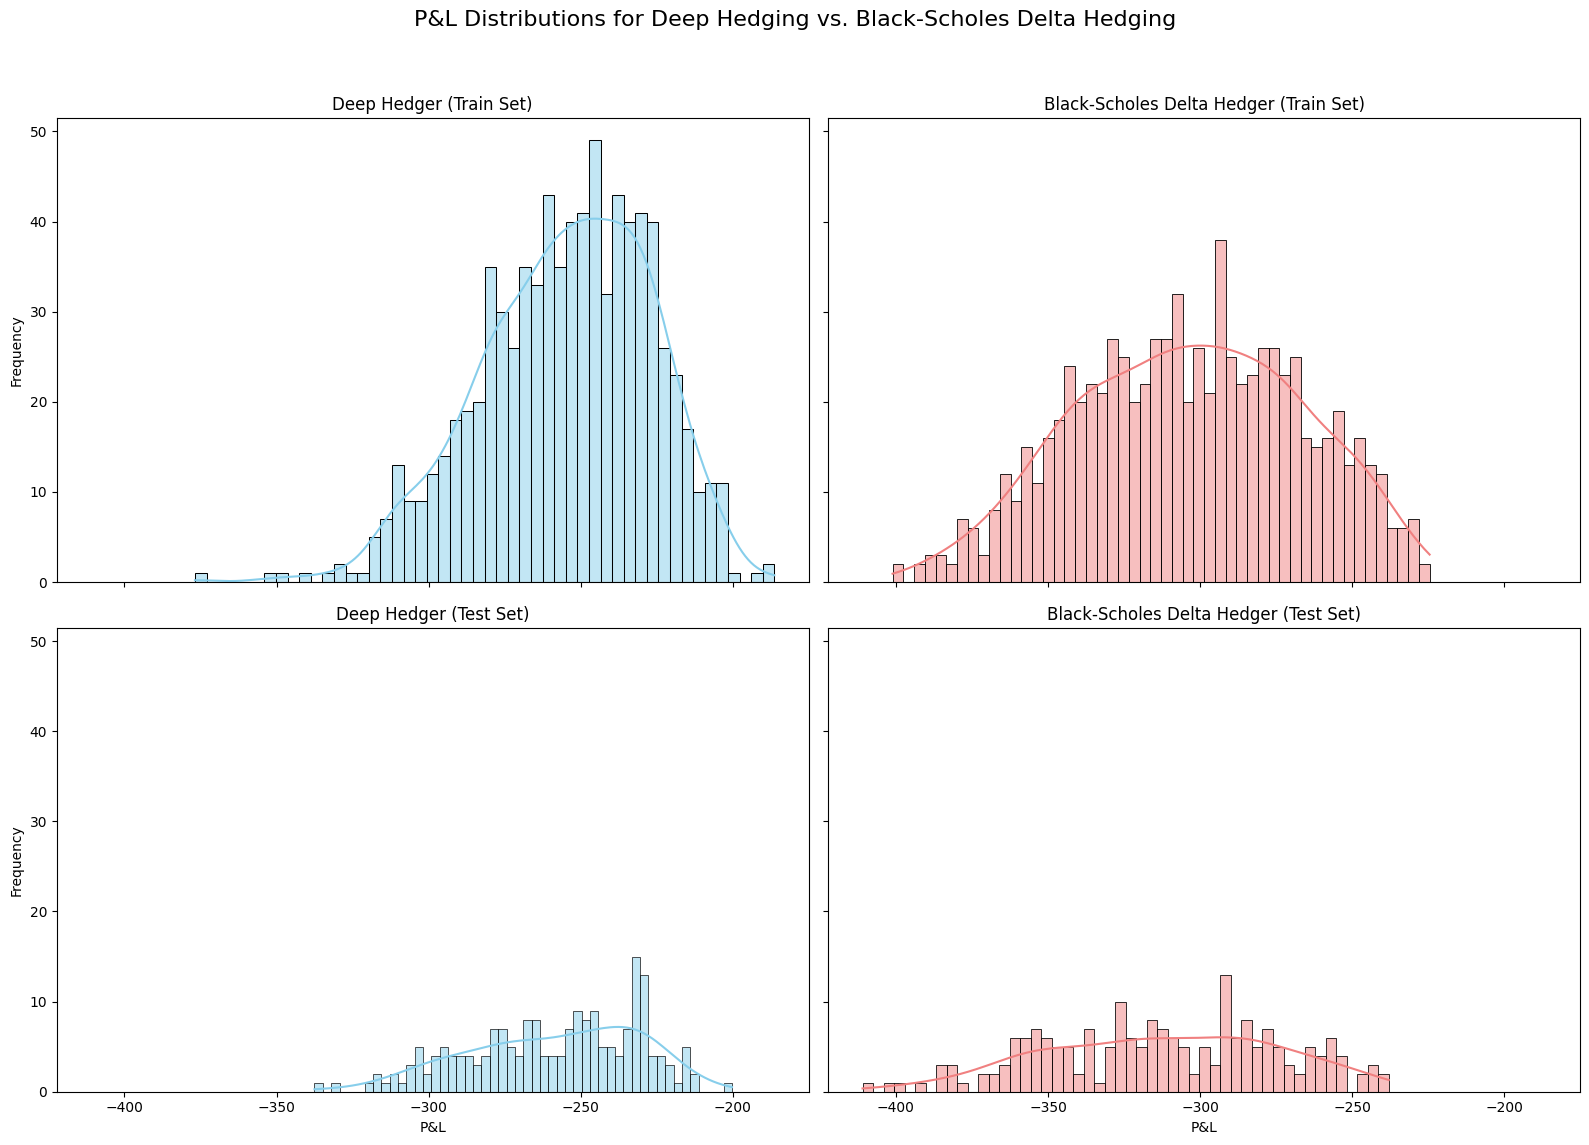


--- Hedging Performance Metrics (alpha = {alph_level:.0%}) ---

Deep Hedger (Train Set):
  Mean P&L: -254.89
  Std Dev P&L: 27.96
  VaR (5%): -305.41
  CVaR (5%): 317.50

Black-Scholes Delta Hedger (Train Set):
  Mean P&L: -303.59
  Std Dev P&L: 36.97
  VaR (5%): -364.56
  CVaR (5%): 376.83

Deep Hedger (Test Set):
  Mean P&L: -258.91
  Std Dev P&L: 27.81
  VaR (5%): -304.67
  CVaR (5%): 316.60

Black-Scholes Delta Hedger (Test Set):
  Mean P&L: -312.77
  Std Dev P&L: 37.99
  VaR (5%): -376.99
  CVaR (5%): 388.69


In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

alph_level = 0.05

# --- Plotting P&L Distributions ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex=True, sharey=True)
fig.suptitle('P&L Distributions for Deep Hedging vs. Black-Scholes Delta Hedging', fontsize=16)

sns.histplot(dh_pnl_train, bins=50, kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Deep Hedger (Train Set)')
axes[0, 0].set_xlabel('P&L')
axes[0, 0].set_ylabel('Frequency')

sns.histplot(bs_pnl_train, bins=50, kde=True, ax=axes[0, 1], color='lightcoral')
axes[0, 1].set_title('Black-Scholes Delta Hedger (Train Set)')
axes[0, 1].set_xlabel('P&L')
axes[0, 1].set_ylabel('Frequency')

sns.histplot(dh_pnl_test, bins=50, kde=True, ax=axes[1, 0], color='skyblue')
axes[1, 0].set_title('Deep Hedger (Test Set)')
axes[1, 0].set_xlabel('P&L')
axes[1, 0].set_ylabel('Frequency')

sns.histplot(bs_pnl_test, bins=50, kde=True, ax=axes[1, 1], color='lightcoral')
axes[1, 1].set_title('Black-Scholes Delta Hedger (Test Set)')
axes[1, 1].set_xlabel('P&L')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# --- Reporting VaR and CVaR ---
print("\n--- Hedging Performance Metrics (alpha = {alph_level:.0%}) ---")

# Deep Hedger Train
mean_pnl_dh_train = np.mean(dh_pnl_train)
std_pnl_dh_train = np.std(dh_pnl_train)
var_dh_train = calculate_var(dh_pnl_train, alpha=alph_level)
cvar_dh_train = calculate_cvar_numpy(dh_pnl_train, alpha=alph_level)
print(f"\nDeep Hedger (Train Set):\n  Mean P&L: {mean_pnl_dh_train:.2f}\n  Std Dev P&L: {std_pnl_dh_train:.2f}\n  VaR ({alph_level:.0%}): {var_dh_train:.2f}\n  CVaR ({alph_level:.0%}): {cvar_dh_train:.2f}")

# Black-Scholes Hedger Train
mean_pnl_bs_train = np.mean(bs_pnl_train)
std_pnl_bs_train = np.std(bs_pnl_train)
var_bs_train = calculate_var(bs_pnl_train, alpha=alph_level)
cvar_bs_train = calculate_cvar_numpy(bs_pnl_train, alpha=alph_level)
print(f"\nBlack-Scholes Delta Hedger (Train Set):\n  Mean P&L: {mean_pnl_bs_train:.2f}\n  Std Dev P&L: {std_pnl_bs_train:.2f}\n  VaR ({alph_level:.0%}): {var_bs_train:.2f}\n  CVaR ({alph_level:.0%}): {cvar_bs_train:.2f}")

# Deep Hedger Test
mean_pnl_dh_test = np.mean(dh_pnl_test)
std_pnl_dh_test = np.std(dh_pnl_test)
var_dh_test = calculate_var(dh_pnl_test, alpha=alph_level)
cvar_dh_test = calculate_cvar_numpy(dh_pnl_test, alpha=alph_level)
print(f"\nDeep Hedger (Test Set):\n  Mean P&L: {mean_pnl_dh_test:.2f}\n  Std Dev P&L: {std_pnl_dh_test:.2f}\n  VaR ({alph_level:.0%}): {var_dh_test:.2f}\n  CVaR ({alph_level:.0%}): {cvar_dh_test:.2f}")

# Black-Scholes Hedger Test
mean_pnl_bs_test = np.mean(bs_pnl_test)
std_pnl_bs_test = np.std(bs_pnl_test)
var_bs_test = calculate_var(bs_pnl_test, alpha=alph_level)
cvar_bs_test = calculate_cvar_numpy(bs_pnl_test, alpha=alph_level)
print(f"\nBlack-Scholes Delta Hedger (Test Set):\n  Mean P&L: {mean_pnl_bs_test:.2f}\n  Std Dev P&L: {std_pnl_bs_test:.2f}\n  VaR ({alph_level:.0%}): {var_bs_test:.2f}\n  CVaR ({alph_level:.0%}): {cvar_bs_test:.2f}")

In [29]:
import numpy as np

# Get the model's predicted deltas on the test set
preds = dh_predicted_deltas_test.numpy().squeeze(-1)  # (200, 375)

print("=== Deep Hedger predicted delta stats ===")
print(f"Min delta:  {preds.min():.4f}")
print(f"Max delta:  {preds.max():.4f}")
print(f"Mean delta: {preds.mean():.4f}")
print(f"Std of delta values (across all paths/steps): {preds.std():.4f}")

# How much does delta change step-to-step, on average? (this is what transaction costs penalize)
delta_changes = np.abs(preds[:, 1:] - preds[:, :-1])
print(f"\nMean |delta change| per step: {delta_changes.mean():.4f}")
print(f"Max  |delta change| per step: {delta_changes.max():.4f}")

print("\n=== Black-Scholes delta stats (for comparison) ===")
bs_deltas_arr = BS_deltas_test  # (200, 375)
print(f"Min delta:  {bs_deltas_arr.min():.4f}")
print(f"Max delta:  {bs_deltas_arr.max():.4f}")
bs_delta_changes = np.abs(bs_deltas_arr[:, 1:] - bs_deltas_arr[:, :-1])
print(f"Mean |delta change| per step: {bs_delta_changes.mean():.4f}")
print(f"Max  |delta change| per step: {bs_delta_changes.max():.4f}")

=== Deep Hedger predicted delta stats ===
Min delta:  0.0610
Max delta:  0.9641
Mean delta: 0.5706
Std of delta values (across all paths/steps): 0.2769

Mean |delta change| per step: 0.0082
Max  |delta change| per step: 0.2675

=== Black-Scholes delta stats (for comparison) ===
Min delta:  0.0000
Max delta:  1.0000
Mean |delta change| per step: 0.0174
Max  |delta change| per step: 0.7988
